# 射频场灵敏度测量（AM 外部调制方案 — dg_am 独立 DC 控制）

利用 Bell-Bloom 磁力仪测量 Z 方向射频场灵敏度。通过 DG4000 AM 外部调制模式产生 X/Y 旋转控制场，dg_sweep CH1 Burst 正弦波输出 Z 射频场，扫描 Z 射频场幅度获得响应曲线，结合 Demod 3 的噪声 PSD 计算灵敏度。

## 涉及设备
| 设备 | 作用 |
|------|------|
| **dg_mod** (DG4E222800868) | CH1: 100MHz 正弦 → RF 开关 IN; CH2: 脉冲门控 (90kHz, 5% 占空比) |
| **dg_comp** (DG4E234902522) | CH1/CH2: X/Y 载波 (90kHz), AM 外部调制模式 |
| **dg_am** | CH1: X AM A(t) 包络 (含 MOD_OFFSET_X); CH2: Y AM A(t) 包络 (含 MOD_OFFSET_Y) |
| **dg_sweep** (DG4E242401288) | CH1: Z 射频场 Burst 正弦 (幅度扫描); CH2: 未使用 |
| **dg_laser** (DG4E231500376) | CH1: Pump 光功率 DC; CH2: Probe 光功率 DC |
| **dg_temp** (DG9Q271200104) | CH2: 温度开关 (5V ON / 0V OFF) |
| **GS200** | 主磁场恒流源 (~9.3 mA) |
| **TEC103** | 气室温度控制 |
| **HF2** (dev18246) | Demod 0: 主信号解调; Demod 3: 射频场解调 (级联 adcselect=2) |
| **SDS 示波器** | C2(X), C3(Y) 监测 AM 调制输出波形 |

## 实验流程
- **环境准备**: 库导入 → 参数配置 → 安全校验 → 设备连接
- **初始值设置**: 光功率/主磁场/温度设定 → Pump 调制启动 → 创建运行目录
- **相位校准**: Demod 0 校相 → X/Y 载波校相 (dg_am A(t) + AM 配置 + 独立校相) → Demod 3 校相
- **数据采集**: Phase A 响应曲线测量 → Phase B 噪声采集
- **数据分析**: 色散拟合 → PSD 分析 → 灵敏度计算
- **安全关闭**: 设备输出关闭 → 连接断开

## 关键参数
- 载波: 90 kHz，X/Y 独立幅度/深度，相位差 90°
- dg_am A(t): 18kHz 方波, 0↔1.3V + 独立 MOD 偏置补偿
- Z 射频场: Z_RF_FREQ = 9 kHz, 幅度扫描 0.01~5.0 V
- Demod 0: TC = 1 ms (校相) / 1 μs (采集), Rate = 100 kSa/s
- Demod 3: TC = 1 ms (响应曲线) / 10 μs (噪声), Rate = 1 kSa/s / 100 kSa/s

## 目录

1. [环境准备](#env) — 库导入、参数配置、安全校验、设备连接
2. [初始值设置](#init) — 光功率/主磁场/温度设定，Pump 调制启动，创建运行目录
3. [相位校准](#phase-cal) — Demod 0 校相 → X/Y 载波校相 → Demod 3 校相
4. [数据采集](#acq) — Phase A 响应曲线扫描 + Phase B DAQ 噪声采集
5. [数据分析](#analysis) — 色散拟合、PSD 分析、灵敏度计算
6. [安全关闭](#cleanup) — 设备输出关闭、连接断开

<a id='env'></a>
## 1. 环境准备

导入依赖库、加载实验参数与安全限值配置、建立仪器连接。

In [1]:
# ========== 交互式绘图模式 ==========
# 启用后图表支持鼠标拖拽平移、滚轮缩放、框选放大
# 如遇到显示问题，可尝试 %matplotlib inline 切换回静态模式
%matplotlib widget

from pathlib import Path
import sys
# 自动定位项目根目录（以 params/ 目录为标记）
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from sds_acquisition import SDSInstrument, SDSAcquisition, AcquisitionConfig, ChannelConfig
from lockin_amplifier import (
    HF2Instrument, DAQConfig, DAQResult,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod, daq,
)

# 数据分析库
from scipy import signal as scipy_signal
from scipy.optimize import curve_fit
# ========== 实验类型 ==========
EXPERIMENT_TYPE = "RF_Field_Sensitivity"
PURPOSE = "rf_field_sensitivity_am_external_modulation"

print("所有库导入成功")

所有库导入成功


In [2]:
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========

# ---- 响应曲线扫描参数（Phase A）----
RF_AMP_START = -1           # Z 射频场幅度扫描起始 (V)
RF_AMP_STOP = 1.0              # Z 射频场幅度扫描终止 (V)
RF_AMP_POINTS = 201            # 扫描点数
RF_SETTLE_TIME = 0.3           # 每点等待稳定时间 (s)

# ---- 噪声采集参数（Phase B）----
NOISE_N_AVG = 10               # 噪声采集平均次数
NOISE_DURATION = 1.0           # 每次噪声采集时长 (s)
NOISE_RATE = 100000            # 噪声采集采样率 (Sa/s)
NOISE_NPERSEG = 10000          # Welch PSD 每段点数

# ---- 包络 A(t) 参数 ----
A_ENV_FREQ = 18000              # A(t) 包络频率 (Hz)
A_ENV_AMPLITUDE = 1.3          # A(t) 包络幅度 (Vpp)，方波 0→1.3V
A_ENV_OFFSET = 0.65             # A(t) DC 偏置 (V)，0~1.3V → offset=0.65
A_ENV_SHAPE = "SQUare"         # 包络波形，使用标准方波（C332000）
A_ENV_K = 23968.44
A_ENV_B = -4
ARB_WAVEFORM_DIR = "arb_waveforms/"  # 自定义 A(t) 波形文件存放目录（仅 USER 模式需要）
ARB_WAVEFORM_FILE = "env_waveform.csv"  # 默认 A(t) 波形文件名
# ★ MOD 偏置补偿: X/Y 零输出点不同, 各自加偏置弥合差距 (dg_am CH1=X, CH2=Y)
MOD_OFFSET_X = -0.143          # X 通道 MOD DC 偏置 (V)
MOD_OFFSET_Y = -0.119        # Y 通道 MOD DC 偏置 (V), +0.015V 补偿 -0.015V 差异

# ---- X/Y 载波参数（AM 外部调制方案，可分别设置）----
# 载波幅度可分别设置，有效 XY 场强由 dg_am CH1/CH2 A(t) 方波通过 AM 调制控制
XY_CARRIER_FREQ = 90e3        # X/Y 载波频率 (Hz)，等于 Larmor 频率
X_CARRIER_AMPLITUDE = 10.0    # X 载波幅值 (Vpp)
Y_CARRIER_AMPLITUDE = 10.0    # Y 载波幅值 (Vpp)
X_CARRIER_PHASE = 0           # CH1 载波初始相位 (deg)，校相后确定
Y_CARRIER_PHASE = 90          # CH2 载波初始相位 (deg)，校相后确定
X_AM_DEPTH = 100           # X 通道 AM 调制深度 (%)
Y_AM_DEPTH = 100           # Y 通道 AM 调制深度 (%)

# ---- Z 射频场参数（dg_sweep CH1 Burst）----
Z_RF_FREQ = 9000              # Z 射频场频率 (Hz)
Z_RF_AMPLITUDE_INIT = 0.1     # Z 射频场幅度初始值 (Vpp)
Z_V_TO_NT = 3517/2
Z_V_TO_FT = Z_V_TO_NT * 1000000

# ---- Pump 调制参数 ----
PUMP_MOD_FREQ = 90000          # Pump 调制频率 (Hz)，与 Larmor 频率一致
PUMP_MOD_DUTY = 5              # 脉冲占空比 (%)
PUMP_MOD_AMPLITUDE = 0.18      # 100MHz 载波幅度 (Vpp)

# ---- HF2 解调器 0 配置（主信号解调）----
# 两个时间常数：校相用小 TC（宽带），采集数据用大 TC（滤波）
DEMOD0_IDX = 0
DEMOD0_OSC_IDX = 0
DEMOD0_OSC_FREQ = 90000
DEMOD0_SIGNAL_RANGE = 2.0
DEMOD0_ORDER = 4
DEMOD0_TC_CALIB = 0.001          # 校相时使用，宽带以保留射频场调制信息
DEMOD0_TC_MEAS = 1e-6          # 采集数据时使用s
DEMOD0_RATE = 100000

# ---- HF2 解调器 3 配置（射频场解调）----
DEMOD3_IDX = 3
DEMOD3_OSC_IDX = 1
DEMOD3_ADC_SELECT = 2          # 信号输入源: 2 = Demod 0 内部 Y 输出
DEMOD3_ORDER = 8
DEMOD3_TC = 0.001              # 响应曲线测量时使用
DEMOD3_RATE = 1000
DEMOD3_NOISE_TC = 1e-5         # 噪声采集时使用（小 TC 高带宽）
DEMOD3_NOISE_ORDER = 4
DEMOD3_NOISE_RATE = NOISE_RATE

# ---- 固定参数 ----
FIXED_PARAMS = {
    "Pump_laser_power": 0.1,      # Pump 光功率 DC (V)
    "Probe_laser_power": 0.1,     # Probe 光功率 DC (V)
    "main_magnetic_field": 9.305, # 主磁场 (mA)
    "temperature": 100,            # 气室温度 (°C)
    "Temp_Switch": 5.0,           # 温度开关 ON (V)
}

print("配置已加载")

# ---- 运行目录命名 ----
RUN_TAG = "rf_sens"

配置已加载


In [4]:
# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错."""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if lo is not None and hi is not None:
        if value < lo or value > hi:
            raise ValueError(
                f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
            )
    return value


devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    # [经验] GS200 需硬件级电流保护
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG4000: X/Y 补偿磁场（AM 载波输出）----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"补偿场 DG4000 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    # Y 通道: 通过同一设备 CH2 控制
    devices["dg_comp"] = dg_comp

    # ---- DG4000: X/Y AM A(t) 独立控制 (dg_am) ----
    # CH1 → dg_comp CH1 MOD Input (X, 含 MOD_OFFSET_X)
    # CH2 → dg_comp CH2 MOD Input (Y, 含 MOD_OFFSET_Y)
    dg_am_cfg = MAPPING["X_magnetic_field_AM"]
    dg_am = DG4000Instrument(dg_am_cfg["resource"], channel=1)
    dg_am.connect()
    print(f"dg_am 已连接: {dg_am.idn()}")
    dg_am.set_ref_clock_source("EXTernal")
    dg_am.setup_dc(0.0, channel=1)
    dg_am.setup_dc(0.0, channel=2)
    dg_am.set_output(False, channel=1)
    dg_am.set_output(False, channel=2)
    devices["dg_am"] = dg_am

    # ---- DG4000: Z 射频场（dg_sweep）----
    # CH1: Z 射频场 Burst 正弦 (幅度扫描)
    # CH2: 本实验未使用 (A(t) 已移至 dg_am)
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"dg_sweep DG4000 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    dg_sweep.setup_dc(0.0, channel=1)
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_output(False, channel=2)
    print(f"  -> CH1 (Z 场): DC 0V, 输出 OFF")
    print(f"  -> CH2: 未使用 (A(t) 已移至 dg_am)")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump 调制 ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- DG4000: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG4000 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

    # ---- SDS 示波器（监测 X/Y AM 调制输出）----
    scope_cfg = MAPPING.get("scope_waveform", {})
    scope_resource = scope_cfg.get("resource", "")
    scope = SDSInstrument(scope_resource)
    scope.connect()
    print(f"示波器已连接: {scope.idn()}")
    devices["scope"] = scope

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
补偿场 DG4000 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
dg_am 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
dg_sweep DG4000 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> CH1 (Z 场): DC 0V, 输出 OFF
  -> CH2: 未使用 (A(t) 已移至 dg_am)
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
光功率 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部
示波器已连接: Siglent Technologies,SDS1204X HD,SDSEV82X900704,6.9.12.1.1.3.8

所有设备连接完成，共 10 个设备


<a id='init'></a>
## 2. 初始值设置

设置固定参数（光功率、主磁场、温度）、等待温度稳定、配置 Pump 调制 RF 开关方案、创建运行目录并保存实验配置。

In [5]:
hfi = devices["hf2"]
tec = devices["tec"]
gs = devices["gs200"]
dg_laser = devices["dg_laser"]
dg_comp = devices["dg_comp"]
dg_sweep = devices["dg_sweep"]
dg_am = devices["dg_am"]
dg_mod = devices["dg_mod"]
dg_temp = devices["dg_temp"]

# ========== 设置固定参数 ==========

# ---- 1. Pump 光功率 ----
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
print(f"Pump 光功率: {FIXED_PARAMS['Pump_laser_power']} V DC")

# ---- 2. Probe 光功率 ----
validate_safety_limit("Probe_laser_power", FIXED_PARAMS["Probe_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Probe_laser_power"], channel=2)
print(f"Probe 光功率: {FIXED_PARAMS['Probe_laser_power']} V DC")

# ---- 3. 主磁场 ----
validate_safety_limit("main_magnetic_field", FIXED_PARAMS["main_magnetic_field"])
gs.set_current(FIXED_PARAMS["main_magnetic_field"] / 1000.0)  # mA -> A
gs.set_output(True)
print(f"主磁场: {FIXED_PARAMS['main_magnetic_field']} mA")

# ---- 4. 温度控制 ----
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    if abs(t - FIXED_PARAMS['temperature']) < 1:
        print(f"温度已稳定: {t:.2f} °C")
        break

# ---- 5. 温度开关 (ON) ----
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")

# ---- 6. dg_am 初始值 (A(t) 尚未配置，先置偏置值) ----
dg_am.setup_dc(MOD_OFFSET_X, channel=1)
dg_am.setup_dc(MOD_OFFSET_Y, channel=2)
dg_am.set_output(False, channel=1)
dg_am.set_output(False, channel=2)
print(f"dg_am CH1(X AM): DC={MOD_OFFSET_X:.3f}V (偏置补偿), 输出 OFF (将在校相中开启)")
print(f"dg_am CH2(Y AM): DC={MOD_OFFSET_Y:.3f}V (偏置补偿), 输出 OFF (将在校相中开启)")

# ========== Pump 调制配置 ==========
# 方案: RF 开关方案
# dg_mod CH1: 100MHz 连续正弦波 → RF 开关 IN
# dg_mod CH2: 脉冲方波 → RF 开关 CTRL (门控)
# RF 开关 OUT → AOM

print("\n--- Pump 调制配置 ---")

# CH1: 100MHz 连续正弦波
validate_safety_limit("Pump_modulation", PUMP_MOD_AMPLITUDE)
dg_mod.setup_sine(freq=100e6, amplitude=PUMP_MOD_AMPLITUDE,
                  offset=0.0, phase=0.0, channel=1)
print(f"CH1: 100MHz 正弦, {PUMP_MOD_AMPLITUDE*1000:.0f} mVpp → RF 开关 IN")

# CH2: 脉冲门控 (Pump 调制频率, 占空比)
validate_safety_limit("Time_sequence", 5.0)  # 5Vpp 在安全范围内
dg_mod.setup_pulse(freq=PUMP_MOD_FREQ, amplitude=5.0,
                   offset=2.5, channel=2)
dg_mod.set_pulse_dcycle(PUMP_MOD_DUTY, channel=2)
print(f"CH2: 脉冲 {PUMP_MOD_FREQ/1000:.0f} kHz, 占空比 {PUMP_MOD_DUTY}%, 5Vpp+2.5V offset")

# CH2 SYNC ON → 作为外部触发源连接至 dg_sweep Ext Trig
dg_mod.set_sync_state(True, channel=2)
print(f"CH2 SYNC: ON (→ dg_sweep Ext Trig)")

# ========== 创建运行目录 ==========
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"\n运行目录: {run_dir}")

# ========== 保存实验配置到运行目录 ==========
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "scan_params": {
        "RF_AMP_START_V": RF_AMP_START,
        "RF_AMP_STOP_V": RF_AMP_STOP,
        "RF_AMP_POINTS": RF_AMP_POINTS,
        "RF_SETTLE_TIME_s": RF_SETTLE_TIME,
    },
    "noise_params": {
        "NOISE_N_AVG": NOISE_N_AVG,
        "NOISE_DURATION_s": NOISE_DURATION,
        "NOISE_RATE_Sa_s": NOISE_RATE,
        "NOISE_NPERSEG": NOISE_NPERSEG,
    },
    "xy_carrier": {
        "XY_CARRIER_FREQ_Hz": XY_CARRIER_FREQ,
        "X_CARRIER_AMPLITUDE_Vpp": X_CARRIER_AMPLITUDE,
        "Y_CARRIER_AMPLITUDE_Vpp": Y_CARRIER_AMPLITUDE,
        "X_AM_DEPTH_pct": X_AM_DEPTH,
        "Y_AM_DEPTH_pct": Y_AM_DEPTH,
        "MOD_OFFSET_X_V": MOD_OFFSET_X,
        "MOD_OFFSET_Y_V": MOD_OFFSET_Y,
    },
    "a_envelope": {
        "A_ENV_FREQ_Hz": A_ENV_FREQ,
        "A_ENV_AMPLITUDE_Vpp": A_ENV_AMPLITUDE,
        "A_ENV_OFFSET_V": A_ENV_OFFSET,
    },
    "z_rf_field": {
        "Z_RF_FREQ_Hz": Z_RF_FREQ,
    },
    "pump_modulation": {
        "PUMP_MOD_FREQ_Hz": PUMP_MOD_FREQ,
        "PUMP_MOD_DUTY_pct": PUMP_MOD_DUTY,
        "PUMP_MOD_AMPLITUDE_Vpp": PUMP_MOD_AMPLITUDE,
    },
    "hf2_demod0": {
        "demod_idx": DEMOD0_IDX,
        "osc_freq_Hz": DEMOD0_OSC_FREQ,
        "signal_range_V": DEMOD0_SIGNAL_RANGE,
        "rate_Sa_s": DEMOD0_RATE,
        "TC_calib_s": DEMOD0_TC_CALIB,
        "TC_meas_s": DEMOD0_TC_MEAS,
        "order": DEMOD0_ORDER,
    },
    "hf2_demod3": {
        "demod_idx": DEMOD3_IDX,
        "adcselect": DEMOD3_ADC_SELECT,
        "TC_response_s": DEMOD3_TC,
        "rate_response_Sa_s": DEMOD3_RATE,
        "TC_noise_s": DEMOD3_NOISE_TC,
        "rate_noise_Sa_s": DEMOD3_NOISE_RATE,
        "order": DEMOD3_ORDER,
    },
    "fixed_params": FIXED_PARAMS,
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

Pump 光功率: 0.1 V DC
Probe 光功率: 0.1 V DC
主磁场: 9.305 mA
温度设定: 100 °C, 当前: 19.9 °C
等待温度稳定...
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19.92 °C
  当前温度: 19

KeyboardInterrupt: 

<a id='phase-cal'></a>
## 3. 相位校准

三阶段校准：Demod 0 主信号校相 → X/Y 载波相位校准（dg_am A(t) 方波+AM 配置+分通道迭代校相）→ Demod 3 射频场校相。

In [46]:
# ============================================================
# Phase 1: Demod 0 相位校准（主信号对齐）
# ============================================================
print("=" * 60)
print("Phase 1: Demod 0 相位校准")
print("=" * 60)

# 关闭所有磁场（消除磁场对校相的干扰）
print("关闭所有磁场...")
# 关闭温控（消除温控线圈磁场）
dg_temp.set_output(False, channel=2)
print("  温度开关: OFF")
# 关闭 X/Y 补偿磁场（AM 载波输出）
dg_comp.set_output(False, channel=1)
dg_comp.set_output(False, channel=2)
print("  X/Y 场: OFF")
# 关闭 dg_am X/Y AM A(t)（在校相阶段不需要）
dg_am.set_output(False, channel=1)
dg_am.set_output(False, channel=2)
print("  X/Y AM A(t): OFF")
# 关闭 Z 射频场
dg_sweep.set_output(False, channel=1)
print("  Z 场: OFF")
time.sleep(0.5)

# 配置信号输入
sig_cfg = SignalInputConfig(
    input_index=0,
    range=DEMOD0_SIGNAL_RANGE,
    ac_coupling=True,
    diff=False,
    impedance=50,
)
demod.configure_signal_input(hfi, sig_cfg)
print(f"信号输入 0: range={DEMOD0_SIGNAL_RANGE} V, AC 耦合")

# 配置振荡器 0 (Pump 调制频率)
osc0_cfg = OscillatorConfig(
    osc_index=DEMOD0_OSC_IDX,
    frequency=DEMOD0_OSC_FREQ,
)
demod.configure_oscillator(hfi, osc0_cfg)
print(f"振荡器 0: {DEMOD0_OSC_FREQ} Hz")

# 配置 Demod 0 (小 TC 以保证宽带响应)
demod0_cfg = DemodulatorConfig(
    demod_index=DEMOD0_IDX,
    enable=True,
    rate=DEMOD0_RATE,
    input_channel=0,
    osc_select=DEMOD0_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD0_TC_CALIB,
    order=DEMOD0_ORDER,
    phase=0.0,
)
actual_rate_d0 = demod.configure_demodulator(hfi, demod0_cfg)
print(f"Demod 0: TC={DEMOD0_TC_CALIB:.0e} s (校相), rate={actual_rate_d0:.0f} Sa/s, order={DEMOD0_ORDER}")

# 自动校相
time.sleep(0.5)  # 等待信号稳定
calibrated_phase_0 = demod.auto_calibrate_phase(
    hfi, demod_idx=DEMOD0_IDX, tolerance_deg=1.0, settle_time=0.2
)
print(f"校准后 Demod 0 相位偏移: {calibrated_phase_0:.2f}°")
time.sleep(0.5)  # 等待信号稳定

# 恢复温控
dg_temp.set_output(True, channel=2)
print("温控已恢复")

Phase 1: Demod 0 相位校准
关闭所有磁场...
  温度开关: OFF
  X/Y 场: OFF
  X/Y AM A(t): OFF
  Z 场: OFF
信号输入 0: range=2.0 V, AC 耦合
振荡器 0: 90000 Hz
Demod 0: TC=1e-03 s (校相), rate=115132 Sa/s, order=4
校准后 Demod 0 相位偏移: -114.28°
温控已恢复


In [47]:
# ============================================================
# Phase 2: X/Y 载波相位校准
# [经验] dg_am CH1→X MOD (含 MOD_OFFSET_X), CH2→Y MOD (含 MOD_OFFSET_Y)
# [经验] A(t) 方波: 低=MOD_OFFSET (XY 场 OFF), 高=MOD_OFFSET+1.3V (XY 场 ON)
# [经验] CH1 和 CH2 载波幅度/深度可分别设置，分通道独立校相
# ============================================================
print("=" * 60)
print("Phase 2: X/Y 载波相位校准")
print("=" * 60)

import math  # noqa: F811

# Step A: 生成 dg_am CH1/CH2 A(t) 方波包络（含独立 MOD 偏置补偿）
# [经验] DG4000 MOD Input 满量程 1.3V，外部 AM 线性响应。
#       方波低电平=MOD_OFFSET → AM 输出=0（自然载波抑制）
#       方波高电平=MOD_OFFSET+1.3V → AM 输出=载波满幅度
print("\n生成 dg_am CH1/CH2 A(t) 方波包络 (含 MOD 偏置)...")

# CH1: X AM A(t) = 方波 MOD_OFFSET_X ↔ MOD_OFFSET_X + 1.3V
# dg_am.setup_square(
#     freq=A_ENV_FREQ,
#     amplitude=A_ENV_AMPLITUDE,
#     offset=A_ENV_OFFSET + MOD_OFFSET_X,
#     dcycle=50.0,
#     channel=1,
# )
A_ENV_OFFSET = (Z_RF_FREQ - A_ENV_B )/ A_ENV_K
print(f"计算得到 A(t) DC 偏置: {A_ENV_OFFSET:.3f} V")
      
dg_am.setup_dc(A_ENV_OFFSET + MOD_OFFSET_X,channel=1)

# CH2: Y AM A(t) = 方波 MOD_OFFSET_Y ↔ MOD_OFFSET_Y + 1.3V
# dg_am.setup_square(
#     freq=A_ENV_FREQ,
#     amplitude=A_ENV_AMPLITUDE,
#     offset=A_ENV_OFFSET + MOD_OFFSET_Y,
#     dcycle=50.0,
#     channel=2,
# )
dg_am.setup_dc(A_ENV_OFFSET + MOD_OFFSET_Y,channel=2)


# Step B: 配置 dg_comp CH1/CH2 AM 外部调制（载波幅度/深度可分别设置）
print("\n配置 X/Y AM 调制载波...")

# CH1: X 载波
dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=X_CARRIER_AMPLITUDE,
                   phase=0.0, channel=1)
dg_comp.set_mod_type("AM", channel=1)
dg_comp.set_mod_am_source("EXT", channel=1)
dg_comp.set_mod_am_depth(X_AM_DEPTH, channel=1)
dg_comp.set_mod_state(True, channel=1)
print(f"CH1: X 载波 {XY_CARRIER_FREQ/1000:.0f} kHz, {X_CARRIER_AMPLITUDE} Vpp, "
      f"AM EXT, 深度 {X_AM_DEPTH}%")

# CH2: Y 载波（可独立设置幅度和深度）
dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=Y_CARRIER_AMPLITUDE,
                   phase=0.0, channel=2)
dg_comp.set_mod_type("AM", channel=2)
dg_comp.set_mod_am_source("EXT", channel=2)
dg_comp.set_mod_am_depth(Y_AM_DEPTH, channel=2)
dg_comp.set_mod_state(True, channel=2)
print(f"CH2: Y 载波 {XY_CARRIER_FREQ/1000:.0f} kHz, {Y_CARRIER_AMPLITUDE} Vpp, "
      f"AM EXT, 深度 {Y_AM_DEPTH}%")

print(f"  MOD 偏置: X={MOD_OFFSET_X:.3f}V, Y={MOD_OFFSET_Y:.3f}V")

# Step C: 分通道校相（在 dg_am 输出开启后进行）
# [经验] 确保 Demod 0 使用校相时间常数（宽带），保证相位测量准确

# 显式设置 Demod 0 为校相 TC
demod0_calib_cfg_phase2 = DemodulatorConfig(
    demod_index=DEMOD0_IDX,
    enable=True,
    rate=DEMOD0_RATE,
    input_channel=0,
    osc_select=DEMOD0_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD0_TC_CALIB,
    order=DEMOD0_ORDER,
    phase=calibrated_phase_0,
)
demod.configure_demodulator(hfi, demod0_calib_cfg_phase2)
print(f"Demod 0: TC={DEMOD0_TC_CALIB:.0e} s (校相, 宽带)")

# [经验] 先开 dg_am 输出，再开 dg_comp 输出进行校相
dg_am.set_output(True, channel=1)
dg_am.set_output(True, channel=2)
print("\ndg_am CH1/CH2 A(t) 输出: ON")

print("\n分通道校相：分别校准 CH1 和 CH2 的载波相位...")
dg_temp.set_output(False, channel=2)

# ---- 校准 CH1 相位 ----
print("\n  校准 CH1 相位...")
# 暂时关闭 CH2（dg_comp CH2 输出 + dg_am CH2），只开 CH1 读 HF2 相位
dg_comp.set_output(False, channel=2)
dg_am.set_output(False, channel=2)
dg_comp.set_output(True, channel=1)
time.sleep(0.5)

for iteration in range(5):
    sample = demod.read_demod_sample(hfi, demod_idx=0)
    phase_offset = math.degrees(sample["theta"])  # atan2(y,x)，解调矢量角度
    print(f"    CH1 迭代 {iteration+1}: theta = {phase_offset:.2f}°")
    if abs(phase_offset) < 0.5:
        print(f"    CH1 相位已收敛 (<0.5°)")
        break
    X_CARRIER_PHASE = (X_CARRIER_PHASE - phase_offset) % 360
    dg_comp.set_phase_adjust(X_CARRIER_PHASE, channel=1)
    time.sleep(0.5)

print(f"    CH1 最终载波相位 = {X_CARRIER_PHASE:.2f}°")

# ---- 在 CH1 相位已校准的基础上，开启 CH2 并修正其单独相位 ----
#   CH2 独立校相，使用参数 Y_CARRIER_PHASE 作为起始值
dg_comp.set_output(True, channel=2)
dg_am.set_output(True, channel=2)
dg_comp.set_phase_adjust(Y_CARRIER_PHASE, channel=2)
time.sleep(0.3)

print("\n  校准 CH2 相位...")
for iteration in range(15):
    sample = demod.read_demod_sample(hfi, demod_idx=0)
    phase_offset = math.degrees(sample["theta"])
    print(f"    CH2 迭代 {iteration+1}: theta = {phase_offset:.2f}°")
    if abs(phase_offset) < 0.5:
        print(f"    CH2 相位已收敛 (<0.5°)")
        break
    Y_CARRIER_PHASE = (Y_CARRIER_PHASE - phase_offset) % 360
    dg_comp.set_phase_adjust(Y_CARRIER_PHASE, channel=2)
    time.sleep(0.5)

dg_temp.set_output(True, channel=2)
print(f"    CH2 最终载波相位 = {Y_CARRIER_PHASE:.2f}°")
print(f"    实际相位差 = {(Y_CARRIER_PHASE - X_CARRIER_PHASE) % 360:.2f}°")

print(f"\n✅ 分通道校相完成")
print(f"  X_CARRIER_PHASE = {X_CARRIER_PHASE:.2f}°")
print(f"  Y_CARRIER_PHASE = {Y_CARRIER_PHASE:.2f}°")

Phase 2: X/Y 载波相位校准

生成 dg_am CH1/CH2 A(t) 方波包络 (含 MOD 偏置)...
计算得到 A(t) DC 偏置: 0.376 V

配置 X/Y AM 调制载波...
CH1: X 载波 90 kHz, 10.0 Vpp, AM EXT, 深度 100%
CH2: Y 载波 90 kHz, 10.0 Vpp, AM EXT, 深度 100%
  MOD 偏置: X=-0.143V, Y=-0.119V
Demod 0: TC=1e-03 s (校相, 宽带)

dg_am CH1/CH2 A(t) 输出: ON

分通道校相：分别校准 CH1 和 CH2 的载波相位...

  校准 CH1 相位...
    CH1 迭代 1: theta = 51.48°
    CH1 迭代 2: theta = 0.16°
    CH1 相位已收敛 (<0.5°)
    CH1 最终载波相位 = 308.52°

  校准 CH2 相位...
    CH2 迭代 1: theta = 16.70°
    CH2 迭代 2: theta = 8.16°
    CH2 迭代 3: theta = 3.96°
    CH2 迭代 4: theta = 1.84°
    CH2 迭代 5: theta = 0.82°
    CH2 迭代 6: theta = 0.36°
    CH2 相位已收敛 (<0.5°)
    CH2 最终载波相位 = 58.52°
    实际相位差 = 109.99°

✅ 分通道校相完成
  X_CARRIER_PHASE = 308.52°
  Y_CARRIER_PHASE = 58.52°


In [48]:
# ============================================================
# Phase 3: Demod 3 相位校准（射频场对齐）
# [经验] Demod 3 的 adcselect = 2 将 Demod 0 的 Y 输出路由为输入
# [经验] 此时需将 Demod 0 切换至 DEMOD0_TC_MEAS（小 TC），
#        保证 Demod 0 输出带宽足以通过 Z 射频场调制信号（~10kHz）
# ============================================================
print("=" * 60)
print("Phase 3: Demod 3 相位校准")
print("=" * 60)

# 切换 Demod 0 至小 TC（宽带模式），为 Demod 3 提供足够的信号带宽
print("切换 Demod 0 至宽带模式（Demod 3 校相需要）...")
demod0_wide_cfg = DemodulatorConfig(
    demod_index=DEMOD0_IDX,
    enable=True,
    rate=DEMOD0_RATE,
    input_channel=0,
    osc_select=DEMOD0_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD0_TC_MEAS,
    order=DEMOD0_ORDER,
    phase=calibrated_phase_0,
)
actual_rate_d0_wide = demod.configure_demodulator(hfi, demod0_wide_cfg)
print(f"Demod 0: TC={DEMOD0_TC_MEAS:.0e} s (宽带), rate={actual_rate_d0_wide:.0f} Sa/s")

# 配置振荡器 1 (Z 射频场频率)
osc1_cfg = OscillatorConfig(
    osc_index=DEMOD3_OSC_IDX,
    frequency=Z_RF_FREQ,
)
demod.configure_oscillator(hfi, osc1_cfg)
print(f"振荡器 1: {Z_RF_FREQ} Hz")

validate_safety_limit("Z_magnetic_field", 0.5)
dg_sweep.setup_sine(freq=Z_RF_FREQ, amplitude=0.1, channel=1)
print(f"Z 射频场: {Z_RF_FREQ/1000:.0f} kHz Burst, 幅度 0.2  Vpp, 外部触发")

# 配置 Demod 3（级联架构：adcselect=2 → Demod 0 Y 输出）
demod3_cfg = DemodulatorConfig(
    demod_index=DEMOD3_IDX,
    enable=True,
    rate=DEMOD3_RATE,
    input_channel=DEMOD3_ADC_SELECT,  # 2 = Demod 0 Y 内部路由
    osc_select=DEMOD3_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD3_TC,
    order=DEMOD3_ORDER,
    phase=0.0,
)
actual_rate_d3 = demod.configure_demodulator(hfi, demod3_cfg)
print(f"Demod 3: adcselect={DEMOD3_ADC_SELECT}, osc={DEMOD3_OSC_IDX}, "
      f"TC={DEMOD3_TC:.0e} s, rate={actual_rate_d3:.0f} Sa/s")

# 自动校相
dg_temp.set_output(False, channel=2)
calibrated_phase_3 = demod.auto_calibrate_phase(
    hfi, demod_idx=DEMOD3_IDX, settle_time=0.2
)
time.sleep(2)
dg_temp.set_output(True, channel=2)
print(f"校准后 Demod 3 相位偏移: {calibrated_phase_3:.2f}°")
print("温控已恢复")

print("\n全部相位校准完成")
print(f"  calibrated_phase_0 = {calibrated_phase_0:.2f}°")
print(f"  calibrated_phase_3 = {calibrated_phase_3:.2f}°")

Phase 3: Demod 3 相位校准
切换 Demod 0 至宽带模式（Demod 3 校相需要）...
Demod 0: TC=1e-06 s (宽带), rate=115132 Sa/s
振荡器 1: 9000 Hz
Z 射频场: 9 kHz Burst, 幅度 0.2  Vpp, 外部触发
Demod 3: adcselect=2, osc=1, TC=1e-03 s, rate=899 Sa/s
校准后 Demod 3 相位偏移: 2.66°
温控已恢复

全部相位校准完成
  calibrated_phase_0 = -114.28°
  calibrated_phase_3 = 2.66°


In [40]:
dg_temp.set_output(False, channel=2)
dg_sweep.setup_sine(freq=Z_RF_FREQ, amplitude=0.05, channel=1)
time.sleep(2)
dg_temp.set_output(True, channel=2)

<a id='acq'></a>
## 4. 数据采集

Phase A — 响应曲线测量：逐点扫描 Z 射频场幅度，读取 Demod 3 的 X/Y/R。
Phase B — 噪声采集：关闭 Z 射频场，DAQ 模块采集 Demod 3 Y 信号噪声。

In [49]:
# ============================================================
# Phase A: 响应曲线测量（幅度扫描）
# [经验] Demod 3 在响应曲线采集时使用较大 TC（1ms）以抑制噪声
# [经验] 负幅度时相位改为 180° 实现极性反转（信号发生器不支持负幅度）
# ============================================================
print("=" * 60)
print("Phase A: 响应曲线测量开始")
print("=" * 60)

# 切换 Demod 0 至测量 TC（滤波降噪）
demod0_meas_cfg = DemodulatorConfig(
    demod_index=DEMOD0_IDX,
    enable=True,
    rate=DEMOD0_RATE,
    input_channel=0,
    osc_select=DEMOD0_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD0_TC_MEAS,
    order=DEMOD0_ORDER,
    phase=calibrated_phase_0,
)
actual_rate_d0_meas = demod.configure_demodulator(hfi, demod0_meas_cfg)
print(f"Demod 0: TC={DEMOD0_TC_MEAS*1000:.1f} ms (数据采集), rate={actual_rate_d0_meas:.0f} Sa/s")

# 设置 Demod 3 为响应曲线测量模式（大 TC 滤波）
demod3_response_cfg = DemodulatorConfig(
    demod_index=DEMOD3_IDX,
    enable=True,
    rate=DEMOD3_RATE,
    input_channel=DEMOD3_ADC_SELECT,
    osc_select=DEMOD3_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD3_TC,
    order=DEMOD3_ORDER,
    phase=calibrated_phase_3,
)
actual_rate_d3_resp = demod.configure_demodulator(hfi, demod3_response_cfg)
print(f"Demod 3 响应曲线模式: TC={DEMOD3_TC*1000:.1f} ms, rate={actual_rate_d3_resp:.0f} Sa/s")

# 生成幅度序列
amplitudes = np.linspace(RF_AMP_START, RF_AMP_STOP, RF_AMP_POINTS)
print(f"扫描: {RF_AMP_START} ~ {RF_AMP_STOP} V, {RF_AMP_POINTS} 点, 每点等待 {RF_SETTLE_TIME*1000:.0f} ms")

# 数据容器
recorded_x = []
recorded_y = []
recorded_r = []

# [经验] 扫描循环须用 try/finally 包裹，确保异常时恢复温度开关
try:
    for i, amp in enumerate(amplitudes):
        # 设置 Z 射频场幅度
        # [经验] 信号发生器无法输出幅度为0的正弦波，amp≈0 时关闭输出
        # [经验] 负幅度时设置相位=180°实现极性反转
        if np.abs(amp) <= 0.001:
            dg_sweep.set_output(False, channel=1)
        else:
            validate_safety_limit("Z_magnetic_field", np.abs(amp))
            if amp < 0:
                dg_sweep.set_phase_adjust(180.0, channel=1)
            else:
                dg_sweep.set_phase_adjust(0.0, channel=1)
            dg_sweep.set_output(True, channel=1)
            dg_sweep.set_amplitude(np.abs(amp), channel=1)
        time.sleep(RF_SETTLE_TIME)

        # 关闭温控，等待 0.3s 使磁场稳定
        dg_temp.set_output(False, channel=2)
        time.sleep(0.3)

        # 读取 Demod 3 的 X/Y/R
        sample = demod.read_demod_sample(hfi, demod_idx=DEMOD3_IDX)
        recorded_x.append(sample["x"])
        recorded_y.append(sample["y"])
        recorded_r.append(sample["r"])

        # 恢复温控，等待 1s 达到热平衡
        dg_temp.set_output(True, channel=2)
        time.sleep(1.0)

        if (i + 1) % 20 == 0 or i == 0:
            print(f"  [{i+1}/{RF_AMP_POINTS}] amp={amp:.3f} V, R={sample['r']:.6f}")

finally:
    # 确保温控恢复
    dg_temp.set_output(True, channel=2)
    print("扫描完成，温控已恢复")

# 保存响应曲线数据
response_data = {
    "amplitudes": amplitudes[:len(recorded_r)],
    "x": np.array(recorded_x),
    "y": np.array(recorded_y),
    "r": np.array(recorded_r),
}
np.savez(raw_dir / "response_data.npz", **response_data)
print(f"响应曲线数据已保存: {raw_dir / 'response_data.npz'}")
print(f"  amplitudes: {len(response_data['amplitudes'])} 点")
print(f"  X range: [{np.min(recorded_x):.4f}, {np.max(recorded_x):.4f}]")
print(f"  Y range: [{np.min(recorded_y):.4f}, {np.max(recorded_y):.4f}]")
print(f"  R range: [{np.min(recorded_r):.4f}, {np.max(recorded_r):.4f}]")

Phase A: 响应曲线测量开始
Demod 0: TC=0.0 ms (数据采集), rate=115132 Sa/s
Demod 3 响应曲线模式: TC=1.0 ms, rate=899 Sa/s
扫描: -1 ~ 1.0 V, 201 点, 每点等待 300 ms
  [1/201] amp=-1.000 V, R=0.166236
  [20/201] amp=-0.810 V, R=0.177720
  [40/201] amp=-0.610 V, R=0.200010
  [60/201] amp=-0.410 V, R=0.233056
  [80/201] amp=-0.210 V, R=0.265389
  [100/201] amp=-0.010 V, R=0.023427
  [120/201] amp=0.190 V, R=0.262271
  [140/201] amp=0.390 V, R=0.241195
  [160/201] amp=0.590 V, R=0.201706
  [180/201] amp=0.790 V, R=0.176224
  [200/201] amp=0.990 V, R=0.168023
扫描完成，温控已恢复
响应曲线数据已保存: d:\Code\exp_agent\data\RF_Field_Sensitivity\0522_1543_rf_sens\raw\response_data.npz
  amplitudes: 201 点
  X range: [-0.2664, -0.0001]
  Y range: [-0.1289, 0.0001]
  R range: [0.0001, 0.2669]


In [50]:
# ============================================================
# Phase B: 噪声测量（DAQ 采集）
# [经验] 噪声采集后必须恢复解调器配置，否则第二次运行异常
# [经验] 每次噪声采集完立即恢复温度开关，防止温度漂移
# ============================================================
print("=" * 60)
print("Phase B: 噪声测量开始")
print("=" * 60)

# 1. 关闭 Z 射频场输出
dg_sweep.set_output(False, channel=1)
print("Z 射频场: 已关闭 (输出 OFF)")

# 2. 切换 Demod 3 至噪声采集参数（小 TC 高带宽）
print("切换 Demod 3 至噪声采集模式...")
noise_demod_cfg = DemodulatorConfig(
    demod_index=DEMOD3_IDX,
    enable=True,
    rate=DEMOD3_NOISE_RATE,
    input_channel=DEMOD3_ADC_SELECT,
    osc_select=DEMOD3_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD3_NOISE_TC,
    order=DEMOD3_NOISE_ORDER,
    phase=calibrated_phase_3,
)
actual_noise_rate = demod.configure_demodulator(hfi, noise_demod_cfg)
print(f"Demod 3 噪声模式: TC={DEMOD3_NOISE_TC:.0e} s, order={DEMOD3_NOISE_ORDER}")
print(f"  rate: {actual_noise_rate:.0f} Sa/s")

# 3. 配置 DAQ 采集参数
# [经验] grid_cols 使用 actual_rate
daq_cfg = DAQConfig(
    device=MAPPING["lockin_r"]["device_id"],
    trigger_type=0,           # 连续采集模式
    duration=NOISE_DURATION,
    grid_cols=int(actual_noise_rate * NOISE_DURATION),
    grid_rows=1,
    grid_mode=2,
    signal_paths=["sample.x"],  # 采集 Demod 3 的 X 输出
)
print(f"DAQ 已配置: duration={NOISE_DURATION}s, grid_cols={daq_cfg.grid_cols}")

# 4. 切换 Demod 0 至测量 TC（滤波降噪）
print("切换 Demod 0 至测量模式...")
demod0_meas_cfg_phaseb = DemodulatorConfig(
    demod_index=DEMOD0_IDX,
    enable=True,
    rate=DEMOD0_RATE,
    input_channel=0,
    osc_select=DEMOD0_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD0_TC_MEAS,
    order=DEMOD0_ORDER,
    phase=calibrated_phase_0,
)
demod.configure_demodulator(hfi, demod0_meas_cfg_phaseb)
print(f"Demod 0: TC={DEMOD0_TC_MEAS*1000:.1f} ms (数据采集)")

# 5. 循环采集噪声（使用 acquire_data 一键采集）
print(f"\n开始采集 {NOISE_N_AVG} 次噪声...")
for n in range(NOISE_N_AVG):
    # 关闭温控
    dg_temp.set_output(False, channel=2)
    time.sleep(0.3)

    # 一键 DAQ 采集
    results = daq.acquire_data(
        hfi, daq_cfg, demod_idx=DEMOD3_IDX,
        actual_rate=actual_noise_rate, timeout=NOISE_DURATION + 10.0,
    )
    noise_y = results[0].values if results else None

    if noise_y is None or len(noise_y) == 0:
        print(f"  ⚠️ 第 {n+1} 次采集未获取到有效数据，跳过")
        dg_temp.set_output(True, channel=2)
        time.sleep(1.0)
        continue

    # 保存噪声数据
    np.save(raw_dir / f"noise_D3_{n:04d}.npy", noise_y)

    # 恢复温控
    dg_temp.set_output(True, channel=2)
    time.sleep(2.0)  # 等待温度恢复稳定

    print(f"  [{n+1}/{NOISE_N_AVG}] 噪声已保存: noise_D3_{n:04d}.npy, "
          f"shape={noise_y.shape}, "
          f"mean={np.mean(noise_y):.6e}, std={np.std(noise_y):.6e}")

# 6. 恢复 Demod 0 至校准 TC（便于后续校相复用）
print("\n恢复解调器至校相配置...")
demod0_calib_cfg_restore = DemodulatorConfig(
    demod_index=DEMOD0_IDX,
    enable=True,
    rate=DEMOD0_RATE,
    input_channel=0,
    osc_select=DEMOD0_OSC_IDX,
    harmonic=1,
    time_constant=DEMOD0_TC_CALIB,
    order=DEMOD0_ORDER,
    phase=calibrated_phase_0,
)
demod.configure_demodulator(hfi, demod0_calib_cfg_restore)
print(f"Demod 0: TC={DEMOD0_TC_CALIB:.0e} s (校相)")

# 7. 恢复 Demod 3 至响应曲线配置（便于后续检查）
# [经验] 噪声测量后必须恢复 Demod 3 的解调器配置，否则第二次运行异常
demod.configure_demodulator(hfi, demod3_response_cfg)
print("Demod 3 已恢复")

print("\nPhase B 噪声测量完成")

Phase B: 噪声测量开始
Z 射频场: 已关闭 (输出 OFF)
切换 Demod 3 至噪声采集模式...
Demod 3 噪声模式: TC=1e-05 s, order=4
  rate: 115132 Sa/s
DAQ 已配置: duration=1.0s, grid_cols=115131
切换 Demod 0 至测量模式...
Demod 0: TC=0.0 ms (数据采集)

开始采集 10 次噪声...
  [1/10] 噪声已保存: noise_D3_0000.npy, shape=(115131,), mean=1.843831e-06, std=1.341577e-03
  [2/10] 噪声已保存: noise_D3_0001.npy, shape=(115131,), mean=1.104092e-05, std=1.382353e-03
  [3/10] 噪声已保存: noise_D3_0002.npy, shape=(115131,), mean=1.437332e-05, std=1.375319e-03
  [4/10] 噪声已保存: noise_D3_0003.npy, shape=(115131,), mean=6.402498e-06, std=1.351486e-03
  [5/10] 噪声已保存: noise_D3_0004.npy, shape=(115131,), mean=-3.508019e-06, std=1.362154e-03
  [6/10] 噪声已保存: noise_D3_0005.npy, shape=(115131,), mean=-1.943940e-06, std=1.329145e-03
  [7/10] 噪声已保存: noise_D3_0006.npy, shape=(115131,), mean=6.857008e-06, std=1.369162e-03
  [8/10] 噪声已保存: noise_D3_0007.npy, shape=(115131,), mean=-6.579676e-06, std=1.409623e-03
  [9/10] 噪声已保存: noise_D3_0008.npy, shape=(115131,), mean=1.627710e-06, std=1.3

<a id='analysis'></a>
## 5. 数据分析

响应曲线色散拟合 → Welch PSD 分析 → 灵敏度计算与绘图。

✅ 从 d:\Code\exp_agent\data\RF_Field_Sensitivity\0522_1543_rf_sens\raw\response_data.npz 加载响应曲线数据成功
Y 色散拟合 (横轴 nT):
  A     = 2.4055e+02 ± 2.0541e+00
  gamma = -468.85 ± 4.66 nT
  B0    = -4.7 ± 2.6 nT
  C     = -1.3260e-02 ± 9.2228e-04
  dY/dB = 1.0943e-03 V/nT = 1.0943e-09 V/fT
  线宽 HWHM: gamma = -468.85 nT = -468851.91 fT
  线宽对应频率: f_linewidth = -6562.2 Hz
  最优工作点 (零交叉): B0 ≈ -4.7 nT = -4661.5 fT

--- 噪声 PSD 分析 ---
找到 10 个噪声文件
PSD 已保存: d:\Code\exp_agent\data\RF_Field_Sensitivity\0522_1543_rf_sens\results\psd_avg.npz
PSD 频率范围: 0.0 ~ 57565.8 Hz, 分辨率 11.5 Hz

--- 灵敏度计算 ---
最小 50 点中位数 (校正后): 1.03e+02 fT/√Hz
分析摘要已保存: d:\Code\exp_agent\data\RF_Field_Sensitivity\0522_1543_rf_sens\results\analysis.json
分析图已保存: d:\Code\exp_agent\data\RF_Field_Sensitivity\0522_1543_rf_sens\results\full_analysis.png


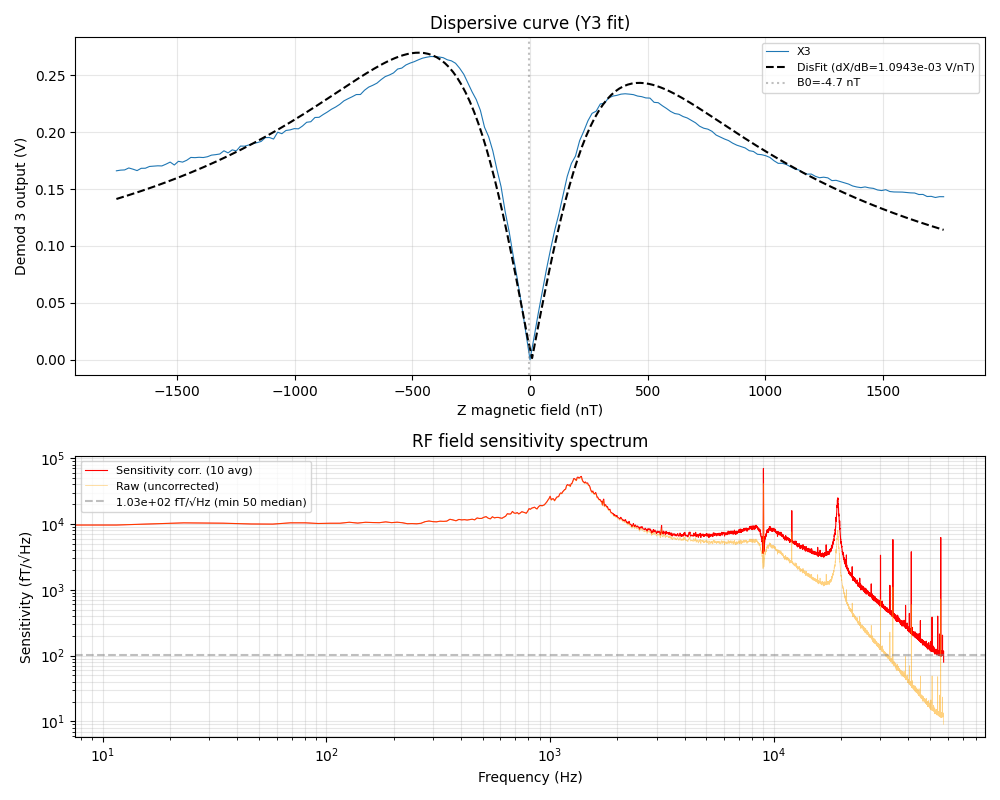

In [54]:
# ============================================================
# 数据分析：Y 色散拟合 + PSD 分析 + 合并绘图
# ============================================================
import json  # noqa: F811

# ---- 加载响应曲线数据 ----
data_path = raw_dir / "response_data.npz"
if data_path.exists():
    loaded = np.load(data_path)
    amps = loaded["amplitudes"]                    # V
    r_vals = loaded["r"]
    x_vals = np.abs(loaded["x"])
    # x_vals = loaded["x"]
    y_vals = loaded["y"]
    print(f"✅ 从 {data_path} 加载响应曲线数据成功")
else:
    raise FileNotFoundError(f"找不到 {data_path}")

# 射频场幅度 → 磁场转换
amps_nT = amps * Z_V_TO_NT                        # nT
amps_fT = amps * Z_V_TO_FT                        # fT

# Larmor 频率常数: f = µ_B·g·B / (4πħ), 碱金属 g≈2
# µ_B/(2πħ) ≈ 28 GHz/T ≈ 28 Hz/nT
muB = 9.2740100783e-24                            # J/T, Bohr magneton
hbar = 1.054571817e-34                            # J·s
larmor_per_nT = muB / (2 * np.pi * hbar) * 1e-9   # ≈ 14 Hz/nT (g≈1 时)

# ============================================================
# 1. Y 色散拟合（横轴: nT, Y 分量与磁场呈色散线形）
# ============================================================
def dispersive(x, A, gamma, x0, C):
    """色散线形: A * (x - x0) / ((x - x0)^2 + gamma^2) + C"""
    return np.abs(A * (x - x0) / ((x - x0)**2 + gamma**2) + C)
    # return A * (x - x0) / ((x - x0)**2 + gamma**2) + C

y_range = float(np.max(y_vals) - np.min(y_vals))
# 初值估算（使用 nT 单位）
B_span_nT = amps_nT[-1] - amps_nT[0]
gamma_est_nT = B_span_nT / 4

p0 = [y_range * gamma_est_nT if gamma_est_nT > 0 else 1.0,
      gamma_est_nT,
      amps_nT[np.argmax(np.abs(np.gradient(y_vals, amps_nT)))],
      np.median(y_vals)]

try:
    popt, pcov = curve_fit(dispersive, amps_nT, x_vals, p0=p0, maxfev=10000)
    A_fit, gamma_nT, B0_nT, C_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # 色散斜率: dY/dB 在 B=B0 处 = A/gamma² (V/nT)
    slope_VnT = abs(A_fit) / (gamma_nT**2) if gamma_nT != 0 else 0.0
    # 转换为 V/fT
    slope_VfT = slope_VnT / 1e6
    opt_nT = B0_nT

    print(f"Y 色散拟合 (横轴 nT):")
    print(f"  A     = {A_fit:.4e} ± {perr[0]:.4e}")
    print(f"  gamma = {gamma_nT:.2f} ± {perr[1]:.2f} nT")
    print(f"  B0    = {B0_nT:.1f} ± {perr[2]:.1f} nT")
    print(f"  C     = {C_fit:.4e} ± {perr[3]:.4e}")
    print(f"  dY/dB = {slope_VnT:.4e} V/nT = {slope_VfT:.4e} V/fT")

    # 生成拟合曲线用于绘图（nT 域）
    B_fine_nT = np.linspace(amps_nT[0], amps_nT[-1], 200)
    x_fit = dispersive(B_fine_nT, *popt)

    # 线宽换算: HWHM (nT) → fT → Larmor 频率 (Hz)
    gamma_fT = gamma_nT * 1000                     # nT → fT
    f_linewidth = gamma_nT * larmor_per_nT          # Hz
    print(f"  线宽 HWHM: gamma = {gamma_nT:.2f} nT = {gamma_fT:.2f} fT")
    print(f"  线宽对应频率: f_linewidth = {f_linewidth:.1f} Hz")
    print(f"  最优工作点 (零交叉): B0 ≈ {opt_nT:.1f} nT = {opt_nT * 1000:.1f} fT")

except Exception as e:
    print(f"拟合失败: {e}")
    print("使用数值差分估计斜率...")
    dy_db = np.gradient(x_vals, amps_nT)
    max_slope_idx = np.argmax(np.abs(dy_db))
    slope_VnT = abs(dy_db[max_slope_idx])
    slope_VfT = slope_VnT / 1e6
    opt_nT = amps_nT[max_slope_idx]
    A_fit = gamma_nT = B0_nT = C_fit = 0
    B_fine_nT = np.array([])
    y_fit = np.array([])
    gamma_fT = 0.0
    f_linewidth = 1000.0

# ============================================================
# 2. 噪声 PSD 分析
# ============================================================
print("\n--- 噪声 PSD 分析 ---")

noise_files = sorted(raw_dir.glob("noise_D3_*.npy"))
if not noise_files:
    print("⚠️ 未找到噪声文件，跳过灵敏度计算")
else:
    n_avg = len(noise_files)
    print(f"找到 {n_avg} 个噪声文件")

    fs = globals().get("actual_noise_rate", NOISE_RATE)
    nperseg = min(NOISE_NPERSEG, len(np.load(noise_files[0])))
    freqs = None
    psd_list = []

    for nf in noise_files:
        noise_data = np.load(nf)
        noise_data = noise_data - np.mean(noise_data)
        f, psd = scipy_signal.welch(noise_data, fs=fs, nperseg=nperseg,
                                     noverlap=nperseg // 2)
        if freqs is None:
            freqs = f
        psd_list.append(psd)

    psd_avg = np.mean(psd_list, axis=0)

    # 保存 PSD
    np.savez(results_dir / "psd_avg.npz",
             freqs=freqs, psd_avg=psd_avg, n_avg=n_avg)
    print(f"PSD 已保存: {results_dir / 'psd_avg.npz'}")
    print(f"PSD 频率范围: {freqs[0]:.1f} ~ {freqs[-1]:.1f} Hz, 分辨率 {freqs[1]-freqs[0]:.1f} Hz")

    # ============================================================
    # 3. 灵敏度计算（单位: fT/√Hz）
    # ============================================================
    print("\n--- 灵敏度计算 ---")

    if abs(slope_VfT) > 1e-15:
        # 灵敏度 = sqrt(PSD) / |dY/dB|  (V/√Hz / (V/fT) = fT/√Hz)
        sens_fT = np.sqrt(psd_avg) / abs(slope_VfT)

        # 响应曲线校正: 补偿有限线宽导致的高频滚降
        correction = np.sqrt(1.0 + (freqs / f_linewidth)**2)
        sens_corrected = sens_fT * correction

        # 灵敏度报告值: 取校正后最优的 N_TOP 个点的中位数
        N_TOP = min(50, len(sens_corrected))
        sens_top = np.sort(sens_corrected)[:N_TOP]
        sens_flat = float(np.median(sens_top))

        print(f"最小 {N_TOP} 点中位数 (校正后): {sens_flat:.2e} fT/√Hz")

        # ---- 保存分析结果 ----
        analysis = {
            "experiment_type": EXPERIMENT_TYPE,
            "purpose": PURPOSE,
            "run_dir": str(run_dir),
            "timestamp": timestamp,
            "response_fit": {
                "A": float(A_fit) if A_fit else 0,
                "gamma_nT": float(gamma_nT),
                "gamma_fT": float(gamma_fT),
                "B0_nT": float(B0_nT) if B0_nT else 0,
                "B0_fT": float(B0_nT * 1000) if B0_nT else 0,
                "C": float(C_fit) if C_fit else 0,
                "slope_V_per_fT": float(slope_VfT),
                "f_linewidth_Hz": float(f_linewidth),
            },
            "noise_psd": {
                "n_avg": n_avg,
                "fs_Hz": float(fs),
                "nperseg": int(nperseg),
                "freq_resolution_Hz": float(freqs[1] - freqs[0]),
            },
            "sensitivity": {
                "sens_flat_fT_per_sqrtHz": sens_flat,
                "n_top": N_TOP,
            },
        }
        with open(results_dir / "analysis.json", "w", encoding="utf-8") as fj:
            json.dump(analysis, fj, indent=2, ensure_ascii=False)
        print(f"分析摘要已保存: {results_dir / 'analysis.json'}")

        # ============================================================
        # 4. 合并绘图: 上=色散曲线(nT), 下=灵敏度(fT/√Hz)
        # ============================================================
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[1.2, 1])

        # 上图: X/Y/R vs 磁场 (nT) + 色散拟合
        ax1.plot(amps_nT, x_vals, "-", lw=0.8, label="X3")
        # ax1.plot(amps_nT, y_vals, "-", lw=0.8, label="Y3")
        # ax1.plot(amps_nT, r_vals, "-", lw=0.8, label="R3")
        if len(x_fit) > 0:
            ax1.plot(B_fine_nT, x_fit, "k--", lw=1.5,
                     label=f"DisFit (dX/dB={slope_VnT:.4e} V/nT)")
        ax1.axvline(opt_nT, color="gray", ls=":", alpha=0.5,
                    label=f"B0={opt_nT:.1f} nT" if opt_nT else "")
        ax1.set_xlabel("Z magnetic field (nT)")
        ax1.set_ylabel("Demod 3 output (V)")
        ax1.set_title("Dispersive curve (Y3 fit)")
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)

        # 下图: 灵敏度谱 (fT/√Hz)
        ax2.loglog(freqs, sens_corrected, "r-", lw=0.8,
                   label=f"Sensitivity corr. ({n_avg} avg)")
        ax2.loglog(freqs, sens_fT, "orange", lw=0.5, alpha=0.5,
                   label="Raw (uncorrected)")
        if sens_flat > 0:
            ax2.axhline(sens_flat, color="gray", ls="--", alpha=0.5,
                        label=f"{sens_flat:.2e} fT/√Hz (min {N_TOP} median)")
        if f_linewidth > 0:
            ax2.axvline(f_linewidth, color="blue", ls=":", alpha=0.4,
                        label=f"HWHM={f_linewidth:.1f} Hz")
        ax2.legend(fontsize=8)
        ax2.set_xlabel("Frequency (Hz)")
        ax2.set_ylabel("Sensitivity (fT/√Hz)")
        ax2.set_title("RF field sensitivity spectrum")
        ax2.grid(True, alpha=0.3, which="both")

        plt.tight_layout()
        fig.savefig(results_dir / "full_analysis.png", dpi=150, bbox_inches="tight")
        print(f"分析图已保存: {results_dir / 'full_analysis.png'}")
        plt.show()
    else:
        print("⚠️ 斜率为零，无法计算灵敏度")

<a id='cleanup'></a>
## 6. 安全关闭

关闭所有设备输出、SYNC 信号，断开连接。

In [6]:
# ---- 断开所有设备（保持输出状态不变） ----

print("正在断开设备（保持输出状态不变）...")

# 1. 关闭 HF2 解调器数据传输（否则 FPGA 持续发数据导致 CF 灯闪烁）
if 'hfi' in dir() and hfi.connected:
    try:
        demod.set_demod_enable(hfi, DEMOD0_IDX, False)
        demod.set_demod_enable(hfi, DEMOD3_IDX, False)
        print(f"  HF2: Demod 0/3 enable=False (停止数据流)")
    except Exception as e:
        print(f"  HF2 解调器关闭失败: {e}")

# 2. 断开所有连接（不改变输出状态）
for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("\n所有设备已断开，输出状态保持断开前的设置。如需关闭输出请手动操作。")

正在断开设备（保持输出状态不变）...
  HF2: Demod 0/3 enable=False (停止数据流)
  gs200 已断开
  dg_comp 已断开
  dg_am 已断开
  dg_sweep 已断开
  dg_mod 已断开
  dg_temp 已断开
  tec 已断开
  dg_laser 已断开
  hf2 已断开
  scope 已断开

所有设备已断开，输出状态保持断开前的设置。如需关闭输出请手动操作。
